# Challenge Server

A single server code that handles all 4 challenges.


### Round lifecycle
```
idle ── start_round(r) ──► active   (60-second timer)
                              │
                              ▼
                  (timer expires OR close_round())
                              │
                              ▼
                       submission_closed   ← submissions rejected
                              │ set_ground_truth(r, GT)
                              ▼
                            scored        ← scores revealed
```


In [ ]:
# 1. Dependencies
!pip install -q flask flask-cors


In [ ]:
# 2. Configuration
CHALLENGE = 'monetary'   # 'wand' | 'monetary' | 'sign' | 'waste'

# Per-team secrets (from TA; deliver one secret token to each team privately)
TEAM_SECRETS = {
    'token_team1_a': 'team1',
    'token_team2_b': 'team2',
    'token_team3_c': 'team3',
    'token_team4_d': 'team4',
    'token_team5_e': 'team5',
} # (example)

TEAMS = list(TEAM_SECRETS.values())

# Round auto-closes after this period.
ROUND_DURATION_SEC = 60


In [ ]:
# 3. Scorer base + Hangul utilities
from collections import defaultdict


class Scorer:
    name = ''
    emoji = ''
    total_rounds = 0
    columns = []
    standings_label = 'Avg Score'

    # ...



In [ ]:
# 4. Four scorers
import unicodedata

class WandScorer(Scorer):
    name='Wand Gesture Recognition'; emoji='🪄'; total_rounds=20; standings_label='Total'
    columns=[{'key':'pred','label':'Prediction','align':'left'},{'key':'score','label':'Score','align':'center'}]
    SPELL_CLASSES=['Expelliarmus','Lumos','Protego','Reducto','Engorgio','ExpectoPatronum','AvadaKedavra','Incendio','WingardiumLeviosa','Crucio','Melofors','Imperio','SalvioHexia','Homorphus','AraniaExumai']

    # ...


class MonetaryScorer(Scorer):
    name='Monetary Calculation'; emoji='💴'; total_rounds=15; standings_label='Avg Rank (lower=better)'
    columns=[{'key':'pred','label':'Predicted KRW','align':'right'},{'key':'dev','label':'|Diff|','align':'right'},{'key':'rank','label':'Round Rank','align':'center'}]

    EXCHANGE_RATE = {'USD':1473.24,
                     'CNY':216.07,
                     'EUR':1738.34,
                     'JPY':9.27806} # example

    # ...


class SignLangScorer(Scorer):
    name='Korean Name Sign Language'; emoji='🤟'; total_rounds=10
    columns=[{'key':'pred','label':'Prediction','align':'left'},{'key':'score','label':'Score','align':'right'}]
    # ...

class WasteScorer(Scorer):
    name='Real-Time Waste Sorting'; emoji='♻️'; total_rounds=10
    WASTE_CLASSES=['can','glass','paper','rigid_plastic','styrofoam','plastic_film']
    columns=[{'key':c,'label':c,'align':'center'} for c in WASTE_CLASSES] + [{'key':'score','label':'Score','align':'right'}]
    # ...

In [ ]:
# 5. Instantiate scorer + print team tokens to share with each team

SCORERS = {'wand': WandScorer(), 'monetary': MonetaryScorer(),
           'sign': SignLangScorer(), 'waste': WasteScorer()}

scorer = SCORERS[CHALLENGE]

print(f'Challenge: {scorer.emoji} {scorer.name} ({scorer.total_rounds} rounds)')
print(f'Round duration: {ROUND_DURATION_SEC}s\n')
print('Team Tokens :')

for sec, team in TEAM_SECRETS.items():
    print(f'  {team}: {sec}')


In [ ]:
# 6. Server state + round lifecycle
from datetime import datetime
from threading import Lock, Timer
import time, secrets as _pysecrets

state_lock = Lock()
state = {
    'current_round': 0,
    'round_status': {},                 # round_id -> 'active'|'closed'|'scored'
    'round_start_ts': {},
    'round_end_ts': {},
    'ground_truth': {},
    'submissions': defaultdict(dict),   # round_id -> {team: {prediction, ts, viz_b64}}
    'issued_tokens': {},                # token -> team_id (set by /register)
    '_timer': None,
}

def _round_status(r):
    return state['round_status'].get(r, 'idle')

def _now():
    return time.time()

def _close_round(r, reason='timeout'):
    # ...
    print(f'\n[auto-close] Round {r} submissions closed ({reason}). '
          f'Now call set_ground_truth({r}, GT) to reveal scores.')
    return True

def start_round(round_id):
    """Start a round; auto-close after ROUND_DURATION_SEC."""
    if state.get('_timer'):
        try: state['_timer'].cancel()
        except: pass
    # ...
    print(f'>> Round {round_id} started. Auto-close in {ROUND_DURATION_SEC}s.')

def close_round(round_id=None):
    """Manually close a round before the timer expires."""
    # ...
    print(f'>> Round {r} closed manually.')

def set_ground_truth(round_id, ground_truth):
    """Set GT after submissions are closed; transitions closed -> scored."""
    gt = scorer.validate_gt(ground_truth)
    # ...
    print(f'>> Round {round_id} GT set: {scorer.gt_display(gt)} -> scores revealed')


In [ ]:
# 7. Aggregation helpers
def scores_per_round():
    # ...
    return out

def standings():
    return scorer.aggregate(scores_per_round())


In [ ]:
# 8. Flask app: /register, /submit, /, /api/state, /api/whoami
from flask import Flask, request, jsonify, render_template_string
from flask_cors import CORS
import threading

app = Flask(__name__)
CORS(app)

DASHBOARD_HTML = ''' '''
# ...

def run_server():
    # ...

if not any(t.name == f'flask-{CHALLENGE}' for t in threading.enumerate()):
    threading.Thread(target=run_server, daemon=True, name=f'flask-{CHALLENGE}').start()
    print(f'Flask server started on port {PORT}')
else:
    print(f'Flask server already running on port {PORT} (routes refreshed)')


In [ ]:
# 9. Cloudflare Tunnel — cross-platform (macOS / Linux / Windows)
import os, platform, shutil, subprocess, tarfile, time, re, urllib.request
from pathlib import Path

def _install_cloudflared():
# ...

LOG_PATH = str(Path.home() / f'.cache/cloudflared/cf_{CHALLENGE}.log')
open(LOG_PATH, 'w').close()
# ...

SERVER_URL = None
# ...

print('=' * 64)
if SERVER_URL:
    print(f'  Dashboard:        {SERVER_URL}/')
    print(f'  Student SERVER_URL: {SERVER_URL}')
else:
    print(f'  Could not extract cloudflared URL. Check {LOG_PATH}')
print('=' * 64)


Screen Sample (Monetary)

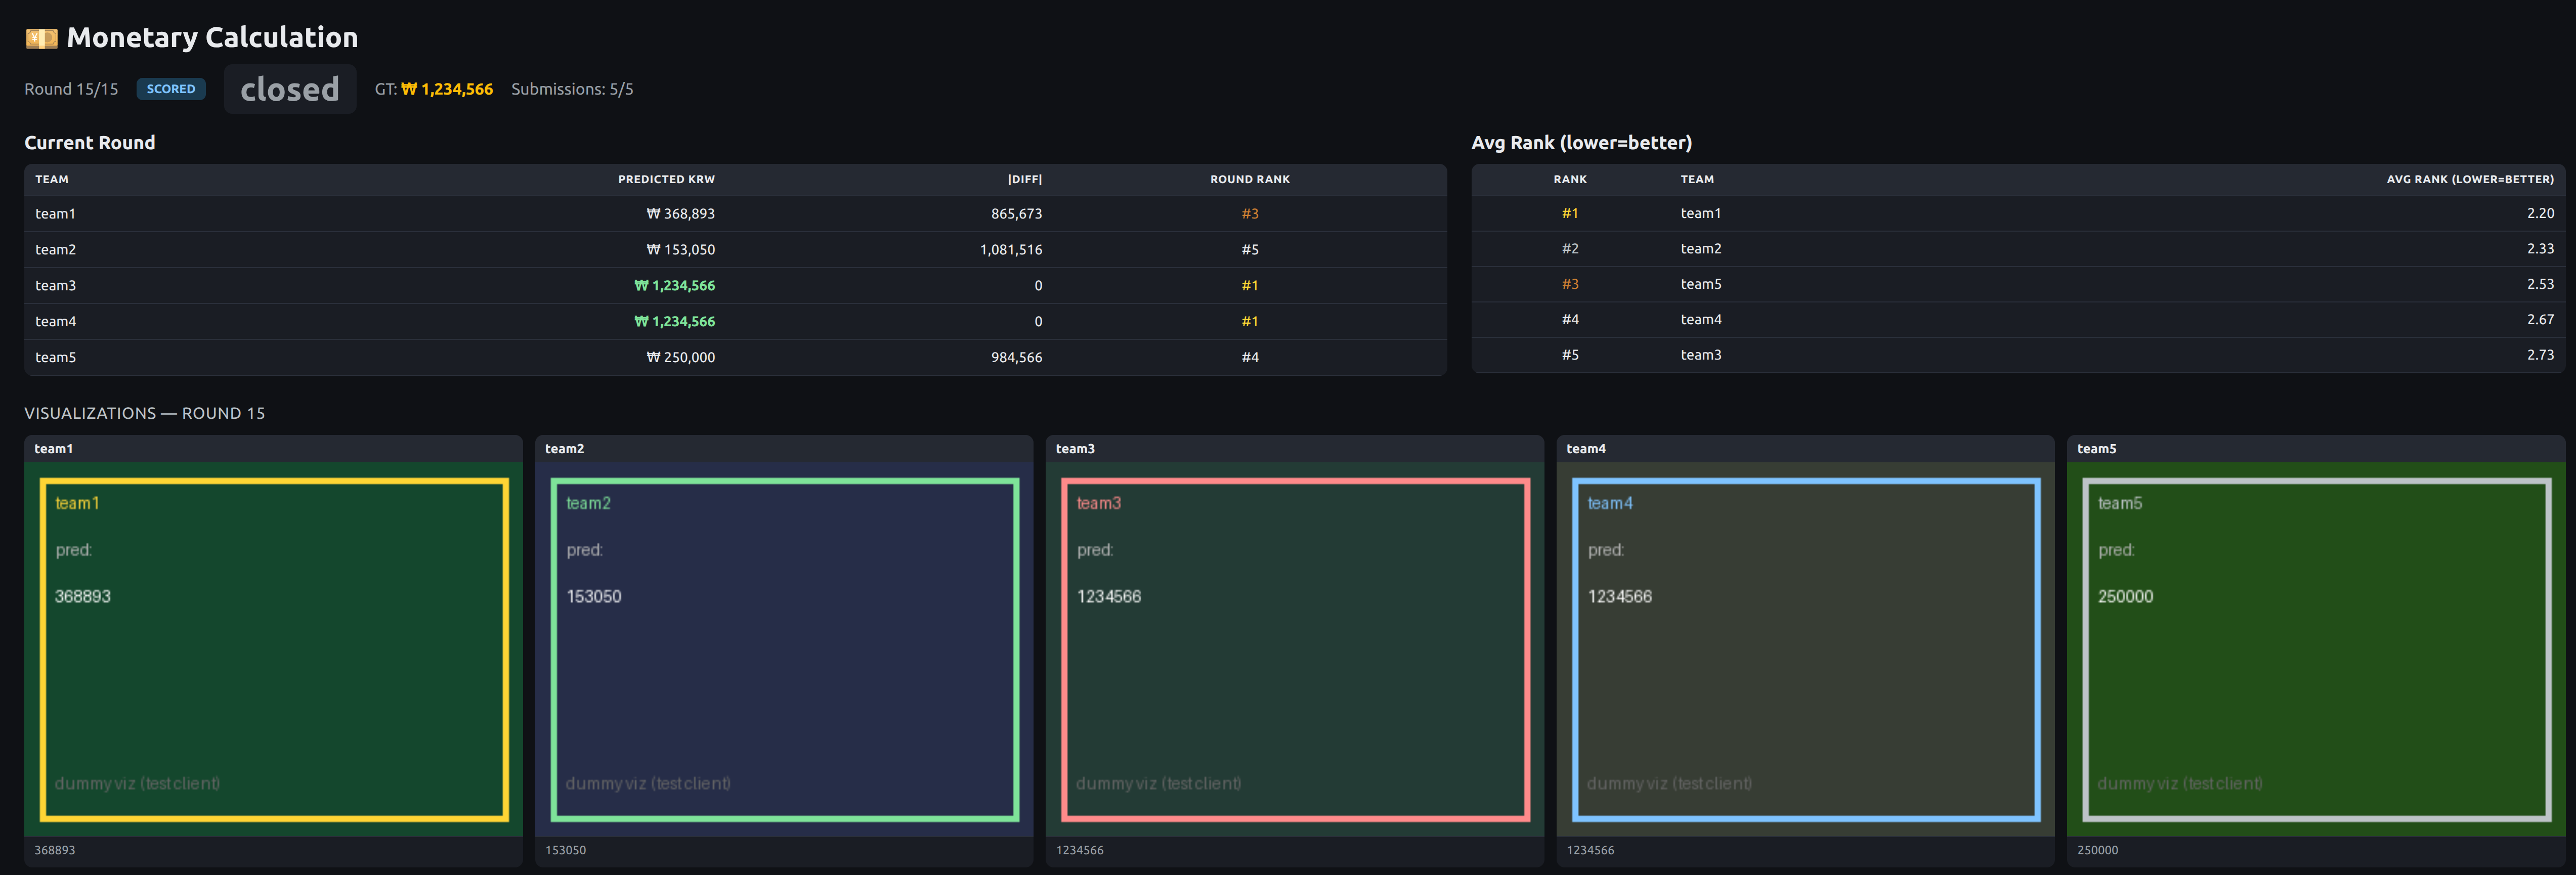

## TA workflow

```python
# 1) Start a round (60-sec timer kicks off)
start_round(1)

# 2) After 60s auto-close (or call manually):
close_round()

# 3) Reveal scores by setting GT
# set_ground_truth(1, 'Lumos')               # wand
set_ground_truth(1, 153053)              # monetary
# set_ground_truth(1, '박상민')             # sign
# set_ground_truth(1, {'can':1, 'glass':1, 'paper':1,
#                     'rigid_plastic':1, 'styrofoam':1, 'plastic_film':1})  # waste

# 4) Next round
start_round(2)
# ...

# 5) Final results
print_final()
```


In [ ]:
# 10. Operations helpers

# show_round(1)
# print_final()
# reset_state()


In [ ]:
reset_state()

State reset (issued tokens cleared too — students must call register again).


In [ ]:
start_round(1)

>> Round 1 started. Auto-close in 60s.


In [ ]:
close_round(1)


[auto-close] Round 1 submissions closed (manual). Now call set_ground_truth(1, GT) to reveal scores.
>> Round 1 closed manually.


In [ ]:
set_ground_truth(1,153053)

>> Round 1 GT set: ₩ 153,053 -> scores revealed


...

In [ ]:
start_round(15)

>> Round 15 started. Auto-close in 60s.


In [ ]:
close_round(15)

In [ ]:
set_ground_truth(15,1234566)

>> Round 15 GT set: ₩ 1,234,566 -> scores revealed


In [ ]:
print_final()

FINAL — Monetary Calculation
  #1  team1     2.20
  #2  team2     2.33
  #3  team5     2.53
  #4  team4     2.67
  #5  team3     2.73


In [ ]:
show_round(15)

-- Round 15 (scored) GT=₩ 1,234,566 --
  team1: pred=368893                                   score=865673.0
  team2: pred=153050                                   score=1081516.0
  team3: pred=1234566                                  score=0.0
  team4: pred=1234566                                  score=0.0
  team5: pred=250000                                   score=984566.0


In [ ]:
# 11. Save all round results (predictions + scores + ranks + visualizations)
import json, base64, shutil
from pathlib import Path
from datetime import datetime

def save_all_results(out_dir='./challenge_runs', include_unscored=False):
    # ...

    # Whole-run summary
    summary = {
        'challenge': CHALLENGE,
        'challenge_name': scorer.name,
        'saved_at': datetime.now().isoformat(timespec='seconds'),
        'total_rounds_in_challenge': scorer.total_rounds,
        'rounds_saved': len(all_rounds),
        'teams': TEAMS,
        'rounds': all_rounds,
        'final_standings': [
            {'rank': r, 'team': t, 'value': v} for r, t, v in standings()
        ],
    }
    # ...

# save_all_results()

In [ ]:
save_all_results()

Saved 15 rounds to: challenge_runs/monetary_20260503_233420
  summary.json:         challenge_runs/monetary_20260503_233420/summary.json
  final_standings.json: challenge_runs/monetary_20260503_233420/final_standings.json
  zip:                  /home/minkyoung/Downloads/server-client2/challenge_runs/monetary_20260503_233420.zip


'challenge_runs/monetary_20260503_233420'